##### Importando Bibliotecas

In [257]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import norm   # plotar a curva gaussiana

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    recall_score,
    precision_score
)



##### Importando DataSet

In [258]:
df = pd.read_csv('merged_data_cleaned.csv')

In [259]:
df.head()

,Unnamed: 0,Species,Owner,Country.of.Origin,Farm.Name,Lot.Number,Mill,ICO.Number,Company,Altitude,...,Color,Category.Two.Defects,Expiration,Certification.Body,Certification.Address,Certification.Contact,unit_of_measurement,altitude_low_meters,altitude_high_meters,altitude_mean_meters
0,0,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,...,Green,0,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
1,1,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,...,Green,1,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
2,2,Arabica,grounds for health admin,Guatemala,"san marcos barrancas ""san cristobal cuch",NaN,NaN,NaN,NaN,1600 - 1800 m,...,NaN,0,"May 31st, 2011",Specialty Coffee Association,36d0d00a3724338ba7937c52a378d085f2172daa,0878a7d4b9d35ddbf0fe2ce69a2062cceb45a660,m,1600.0,1800.0,1700.0
3,3,Arabica,yidnekachew dabessa,Ethiopia,yidnekachew dabessa coffee plantation,NaN,wolensu,NaN,yidnekachew debessa coffee plantation,1800-2200,...,Green,2,"March 25th, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1800.0,2200.0,2000.0
4,4,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,...,Green,2,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0


In [260]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1339 entries, 0 to 1338
Data columns (total 44 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             1339 non-null   int64  
 1   Species                1339 non-null   object 
 2   Owner                  1332 non-null   object 
 3   Country.of.Origin      1338 non-null   object 
 4   Farm.Name              980 non-null    object 
 5   Lot.Number             276 non-null    object 
 6   Mill                   1021 non-null   object 
 7   ICO.Number             1180 non-null   object 
 8   Company                1130 non-null   object 
 9   Altitude               1113 non-null   object 
 10  Region                 1280 non-null   object 
 11  Producer               1107 non-null   object 
 12  Number.of.Bags         1339 non-null   int64  
 13  Bag.Weight             1339 non-null   object 
 14  In.Country.Partner     1339 non-null   object 
 15  Harv

##### Verificando Nulos

In [261]:
df.isnull().sum()

Unnamed: 0                  0
Species                     0
Owner                       7
Country.of.Origin           1
Farm.Name                 359
Lot.Number               1063
Mill                      318
ICO.Number                159
Company                   209
Altitude                  226
Region                     59
Producer                  232
Number.of.Bags              0
Bag.Weight                  0
In.Country.Partner          0
Harvest.Year               47
Grading.Date                0
Owner.1                     7
Variety                   226
Processing.Method         170
Aroma                       0
Flavor                      0
Aftertaste                  0
Acidity                     0
Body                        0
Balance                     0
Uniformity                  0
Clean.Cup                   0
Sweetness                   0
Cupper.Points               0
Total.Cup.Points            0
Moisture                    0
Category.One.Defects        0
Quakers   

#### Tratando Nulos

##### A função abaixo foi utilizada para ver a proporção de nulos por coluna. Colunas com mais de 60% linhas com valores, serão excluídas.

In [262]:
df.isnull().sum()/len(df)*100

Unnamed: 0                0.000000
Species                   0.000000
Owner                     0.522778
Country.of.Origin         0.074683
Farm.Name                26.811053
Lot.Number               79.387603
Mill                     23.749066
ICO.Number               11.874533
Company                  15.608663
Altitude                 16.878267
Region                    4.406273
Producer                 17.326363
Number.of.Bags            0.000000
Bag.Weight                0.000000
In.Country.Partner        0.000000
Harvest.Year              3.510082
Grading.Date              0.000000
Owner.1                   0.522778
Variety                  16.878267
Processing.Method        12.696042
Aroma                     0.000000
Flavor                    0.000000
Aftertaste                0.000000
Acidity                   0.000000
Body                      0.000000
Balance                   0.000000
Uniformity                0.000000
Clean.Cup                 0.000000
Sweetness           

##### Removendo Coluna Lot.Number

In [263]:
df = df.drop(columns=['Lot.Number'])

In [264]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1339 entries, 0 to 1338
Data columns (total 43 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             1339 non-null   int64  
 1   Species                1339 non-null   object 
 2   Owner                  1332 non-null   object 
 3   Country.of.Origin      1338 non-null   object 
 4   Farm.Name              980 non-null    object 
 5   Mill                   1021 non-null   object 
 6   ICO.Number             1180 non-null   object 
 7   Company                1130 non-null   object 
 8   Altitude               1113 non-null   object 
 9   Region                 1280 non-null   object 
 10  Producer               1107 non-null   object 
 11  Number.of.Bags         1339 non-null   int64  
 12  Bag.Weight             1339 non-null   object 
 13  In.Country.Partner     1339 non-null   object 
 14  Harvest.Year           1292 non-null   object 
 15  Grad

###### removendo linhas nulas das colunas escolhidas

In [265]:
df.dropna(subset=['Owner'], inplace=True)

In [266]:
df.dropna(subset=['Country.of.Origin'], inplace=True)

In [267]:
df.dropna(subset=['Owner.1'], inplace=True)

In [268]:
df.dropna(subset=['Quakers'], inplace=True)

##### Colunas númericas com poucos nulos

##### Preenchendo colunas númericas com mediana

In [269]:
df['altitude_low_meters'].fillna(df['altitude_low_meters'].median(), inplace=True)
df['altitude_high_meters'].fillna(df['altitude_high_meters'].median(), inplace=True)
df['altitude_mean_meters'].fillna(df['altitude_mean_meters'].median(), inplace=True)

/tmp/ipykernel_33444/1008574717.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['altitude_low_meters'].fillna(df['altitude_low_meters'].median(), inplace=True)
/tmp/ipykernel_33444/1008574717.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col

##### Colunas categóricas (object ou category) com poucos nulos

In [270]:
df.dtypes

Unnamed: 0                 int64
Species                   object
Owner                     object
Country.of.Origin         object
Farm.Name                 object
Mill                      object
ICO.Number                object
Company                   object
Altitude                  object
Region                    object
Producer                  object
Number.of.Bags             int64
Bag.Weight                object
In.Country.Partner        object
Harvest.Year              object
Grading.Date              object
Owner.1                   object
Variety                   object
Processing.Method         object
Aroma                    float64
Flavor                   float64
Aftertaste               float64
Acidity                  float64
Body                     float64
Balance                  float64
Uniformity               float64
Clean.Cup                float64
Sweetness                float64
Cupper.Points            float64
Total.Cup.Points         float64
Moisture  

#### valores númericos =   Category.Two.Defects / altitude_low_meters / altitude_high_meters / altitude_mean_meters

In [271]:
df.isnull().sum()/len(df)*100

Unnamed: 0                0.000000
Species                   0.000000
Owner                     0.000000
Country.of.Origin         0.000000
Farm.Name                26.842105
Mill                     23.834586
ICO.Number               11.954887
Company                  15.639098
Altitude                 16.917293
Region                    4.360902
Producer                 17.293233
Number.of.Bags            0.000000
Bag.Weight                0.000000
In.Country.Partner        0.000000
Harvest.Year              3.458647
Grading.Date              0.000000
Owner.1                   0.000000
Variety                  16.917293
Processing.Method        12.706767
Aroma                     0.000000
Flavor                    0.000000
Aftertaste                0.000000
Acidity                   0.000000
Body                      0.000000
Balance                   0.000000
Uniformity                0.000000
Clean.Cup                 0.000000
Sweetness                 0.000000
Cupper.Points       

##### Preenchendo colunas categóricas com poucos nulos

Para colunas categóricas, utilizamos a **moda** (valor mais frequente) ou o texto `'Desconhecido'`, pois não faz sentido calcular média para variáveis de texto.

In [272]:
# Moda para colunas onde o valor predominante faz sentido
df['Color'].fillna(df['Color'].mode()[0], inplace=True)
df['Processing.Method'].fillna(df['Processing.Method'].mode()[0], inplace=True)
df['Harvest.Year'].fillna(df['Harvest.Year'].mode()[0], inplace=True)
df['Region'].fillna('Desconhecido', inplace=True)

# 'Desconhecido' para colunas com muitos nulos onde a moda seria enganosa
df['Variety'].fillna('Desconhecido', inplace=True)
df['Farm.Name'].fillna('Desconhecido', inplace=True)
df['Mill'].fillna('Desconhecido', inplace=True)
df['Company'].fillna('Desconhecido', inplace=True)
df['Producer'].fillna('Desconhecido', inplace=True)
df['ICO.Number'].fillna('Desconhecido', inplace=True)
df['Altitude'].fillna('Desconhecido', inplace=True)

/tmp/ipykernel_33444/222353287.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Color'].fillna(df['Color'].mode()[0], inplace=True)
/tmp/ipykernel_33444/222353287.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)

##### Confirmando que não há mais valores nulos

In [273]:
df.isnull().sum()

Unnamed: 0               0
Species                  0
Owner                    0
Country.of.Origin        0
Farm.Name                0
Mill                     0
ICO.Number               0
Company                  0
Altitude                 0
Region                   0
Producer                 0
Number.of.Bags           0
Bag.Weight               0
In.Country.Partner       0
Harvest.Year             0
Grading.Date             0
Owner.1                  0
Variety                  0
Processing.Method        0
Aroma                    0
Flavor                   0
Aftertaste               0
Acidity                  0
Body                     0
Balance                  0
Uniformity               0
Clean.Cup                0
Sweetness                0
Cupper.Points            0
Total.Cup.Points         0
Moisture                 0
Category.One.Defects     0
Quakers                  0
Color                    0
Category.Two.Defects     0
Expiration               0
Certification.Body       0
C

In [274]:
df.shape

(1330, 43)

## 2.3 Análise Exploratória de Dados (EDA)

##### Distribuição da variável categórica de interesse: `Color`

A variável `Color` representa a cor dos grãos de café e é a variável categórica de interesse para a análise probabilística.

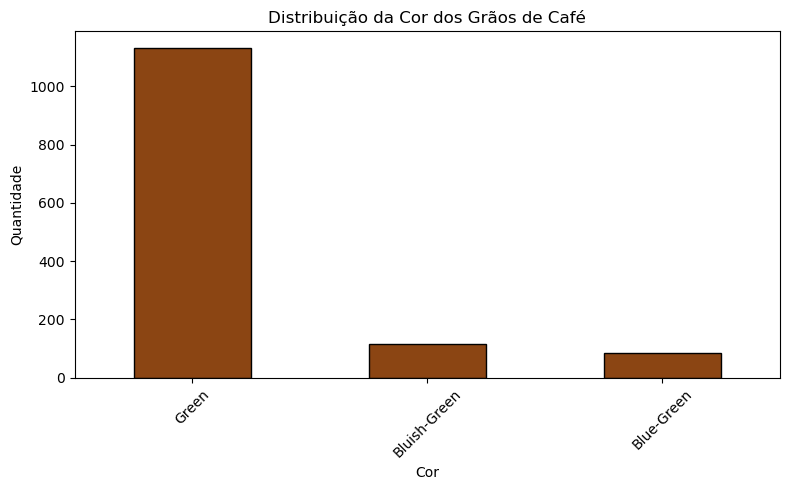

In [275]:
plt.figure(figsize=(8, 5))
df['Color'].value_counts().plot(kind='bar', color='saddlebrown', edgecolor='black')
plt.title('Distribuição da Cor dos Grãos de Café')
plt.xlabel('Cor')
plt.ylabel('Quantidade')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### Distribuição da pontuação total dos cafés (`Total.Cup.Points`)

Variável quantitativa contínua que representa a qualidade geral do café. Permite identificar como a qualidade está distribuída e se há outliers.

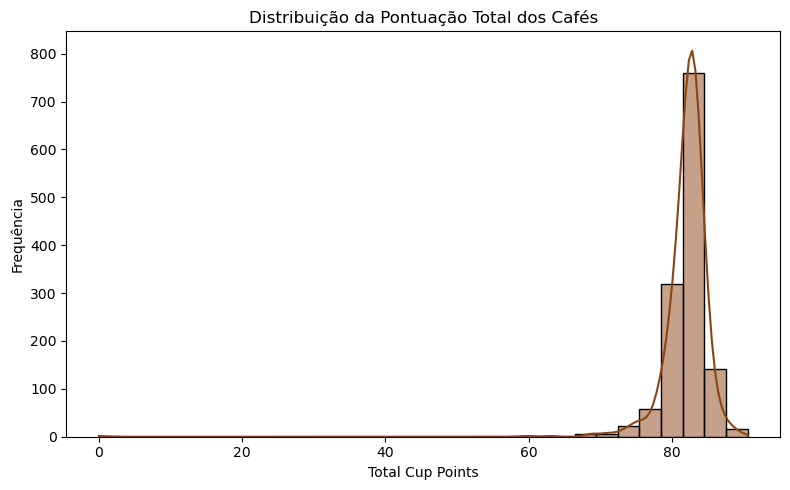

In [276]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Total.Cup.Points'], bins=30, kde=True, color='saddlebrown')
plt.title('Distribuição da Pontuação Total dos Cafés')
plt.xlabel('Total Cup Points')
plt.ylabel('Frequência')
plt.tight_layout()
plt.show()

##### Pontuação total por país de origem (Top 10)

Comparação da qualidade do café entre os principais países produtores.

/tmp/ipykernel_33444/684539883.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top, x='Country.of.Origin', y='Total.Cup.Points', palette='YlOrBr')


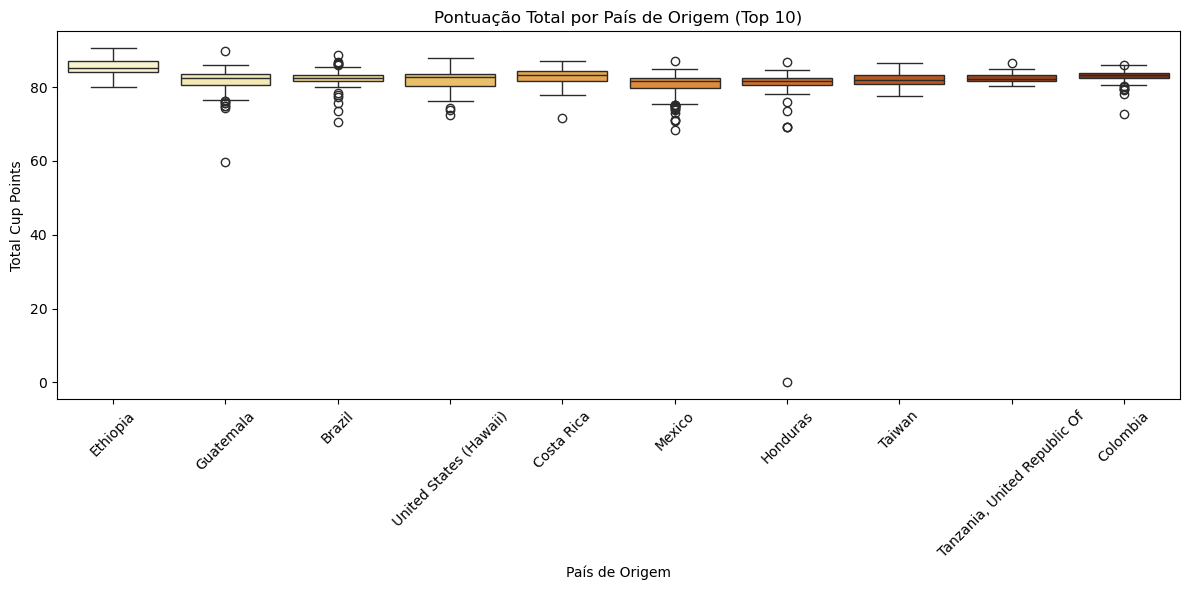

In [277]:
top_paises = df['Country.of.Origin'].value_counts().head(10).index
df_top = df[df['Country.of.Origin'].isin(top_paises)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_top, x='Country.of.Origin', y='Total.Cup.Points', palette='YlOrBr')
plt.title('Pontuação Total por País de Origem (Top 10)')
plt.xlabel('País de Origem')
plt.ylabel('Total Cup Points')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### Correlação entre os atributos de qualidade do café

O mapa de calor mostra a correlação entre as variáveis numéricas de qualidade. Correlações altas indicam atributos que tendem a variar juntos.

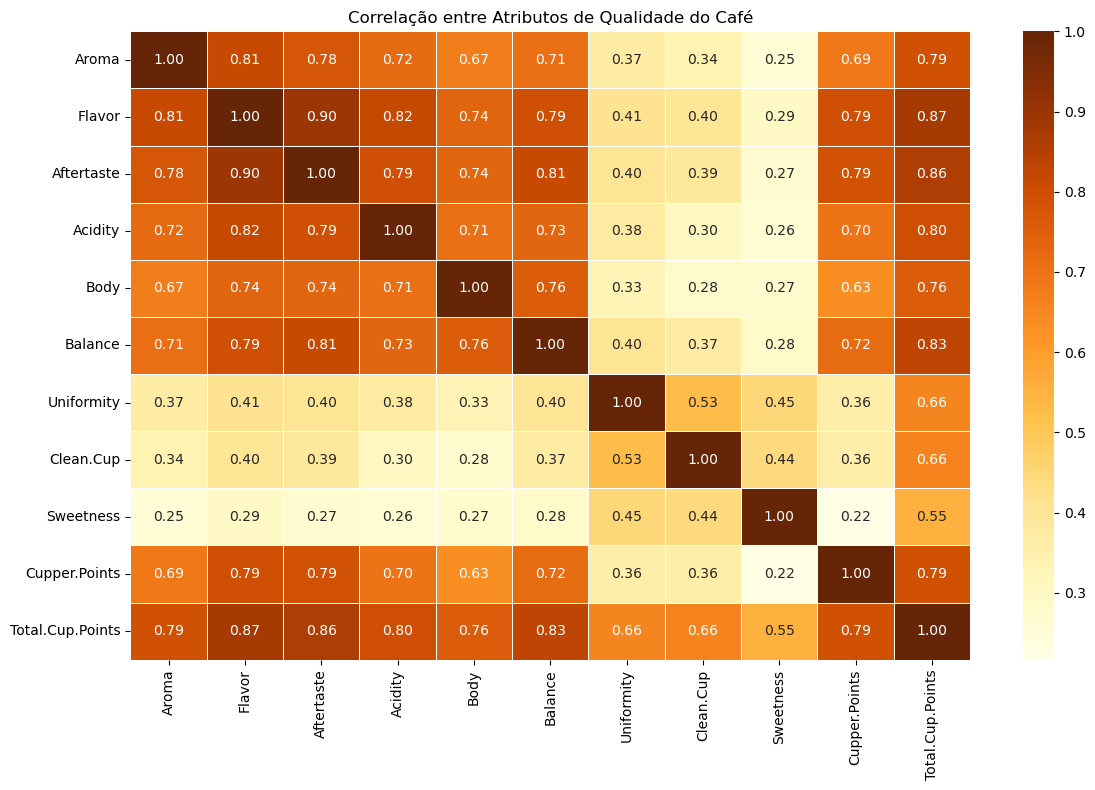

In [278]:
colunas_qualidade = ['Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body',
                     'Balance', 'Uniformity', 'Clean.Cup', 'Sweetness',
                     'Cupper.Points', 'Total.Cup.Points']

plt.figure(figsize=(12, 8))
sns.heatmap(df[colunas_qualidade].corr(), annot=True, fmt='.2f',
            cmap='YlOrBr', linewidths=0.5)
plt.title('Correlação entre Atributos de Qualidade do Café')
plt.tight_layout()
plt.show()

##### Distribuição por método de processamento

Variável qualitativa que indica como o café foi processado. Permite entender quais métodos predominam na amostra.

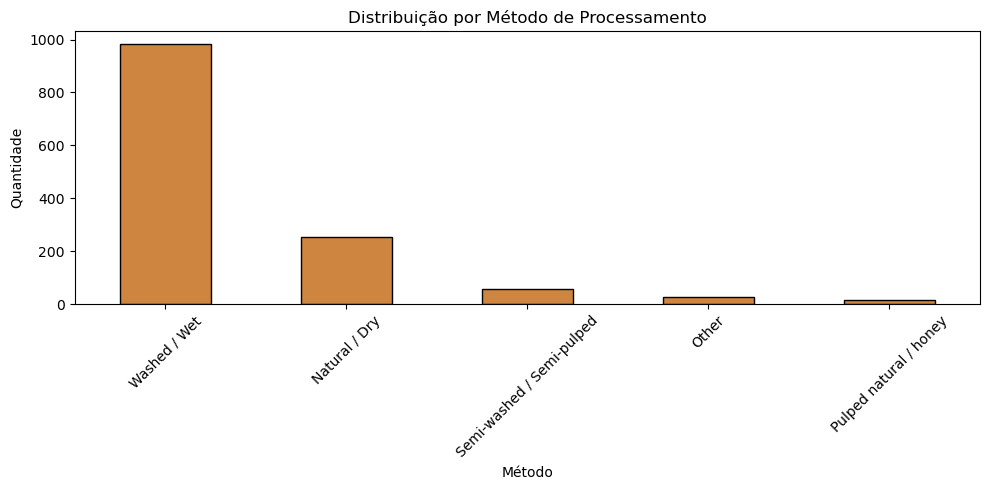

In [279]:
plt.figure(figsize=(10, 5))
df['Processing.Method'].value_counts().plot(kind='bar', color='peru', edgecolor='black')
plt.title('Distribuição por Método de Processamento')
plt.xlabel('Método')
plt.ylabel('Quantidade')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### Relação entre cor do grão e pontuação total

Verifica se a cor do grão está associada a uma maior qualidade do café — útil para embasar a análise probabilística com o Teorema de Bayes.

/tmp/ipykernel_33444/1081282057.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Color', y='Total.Cup.Points', palette='copper')


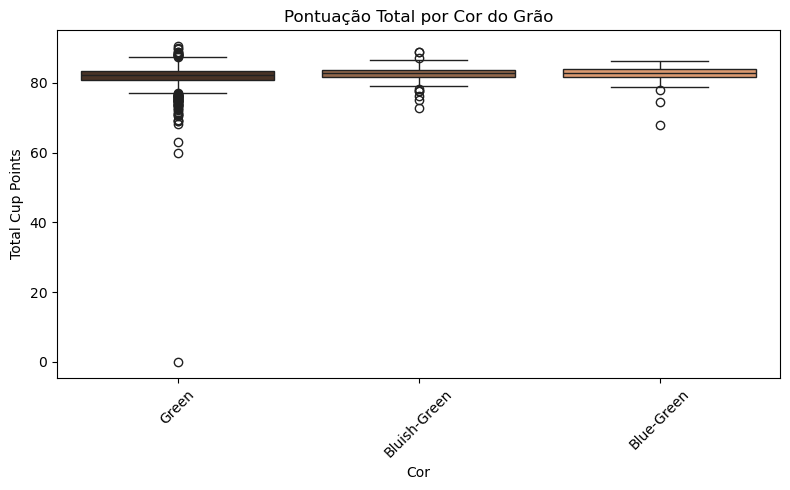

In [280]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Color', y='Total.Cup.Points', palette='copper')
plt.title('Pontuação Total por Cor do Grão')
plt.xlabel('Cor')
plt.ylabel('Total Cup Points')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 2.4 Análise de Probabilidade com o Teorema de Bayes

### Definição das variáveis utilizadas

In [281]:
TARGET     = 'Species'                        # variável alvo (categórica)
PREDICTORS = ['Aroma', 'Flavor', 'Acidity', 'Body']   # variáveis preditoras (contínuas)
CLASSES    = df[TARGET].unique().tolist()     # ['Arabica', 'Robusta']
 
print()
print("1. VARIÁVEIS DEFINIDAS")
print(f"Variável alvo     : {TARGET}")
print(f"Classes           : {CLASSES}")
print(f"Variáveis pred.   : {PREDICTORS}")


1. VARIÁVEIS DEFINIDAS
Variável alvo     : Species
Classes           : ['Arabica', 'Robusta']
Variáveis pred.   : ['Aroma', 'Flavor', 'Acidity', 'Body']


### 2.4.2 Probabilidades a Priori P(C)

P(Arabica) = 1302 / 1330 = 0.978947  (97.89%)
P(Robusta) = 28 / 1330 = 0.021053  (2.11%)


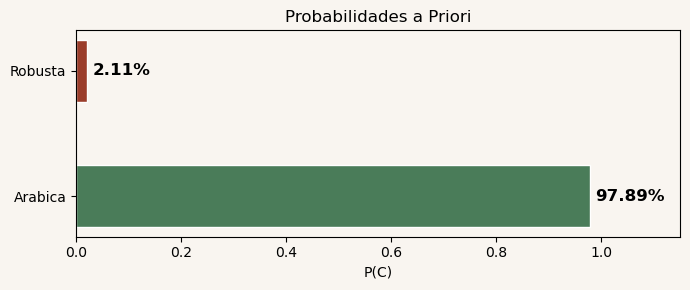

In [282]:
total  = len(df)
priors = {}
 
for cls in CLASSES:
    n = (df[TARGET] == cls).sum()
    priors[cls] = n / total
    print(f"P({cls}) = {n} / {total} = {priors[cls]:.6f}  ({priors[cls]*100:.2f}%)")
 
cores = {'Arabica': '#4a7c59', 'Robusta': '#9b3d2b'}
 
fig, ax = plt.subplots(figsize=(7, 3))
bars = ax.barh(list(priors.keys()), list(priors.values()),
               color=[cores[c] for c in priors], height=0.5, edgecolor='white')
ax.set_xlim(0, 1.15)
for bar, (cls, val) in zip(bars, priors.items()):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val*100:.2f}%', va='center', fontsize=12, fontweight='bold')
ax.set_xlabel('P(C)')
ax.set_title('Probabilidades a Priori')
ax.set_facecolor('#f9f5f0')
fig.patch.set_facecolor('#f9f5f0')
plt.tight_layout()
plt.savefig('grafico_priors.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.4.3 Parâmetros de verossimilhança - Distribuição Gaussiana


Variável     |  μ Arabica  σ Arabica |  μ Robusta  σ Robusta
------------------------------------------------------------
  Aroma      |     7.5648     0.3791 |     7.7025     0.2962
  Flavor     |     7.5188     0.4006 |     7.6307     0.3037
  Acidity    |     7.5336     0.3823 |     7.6571     0.2618
  Body       |     7.5183     0.3601 |     7.5068     0.7252


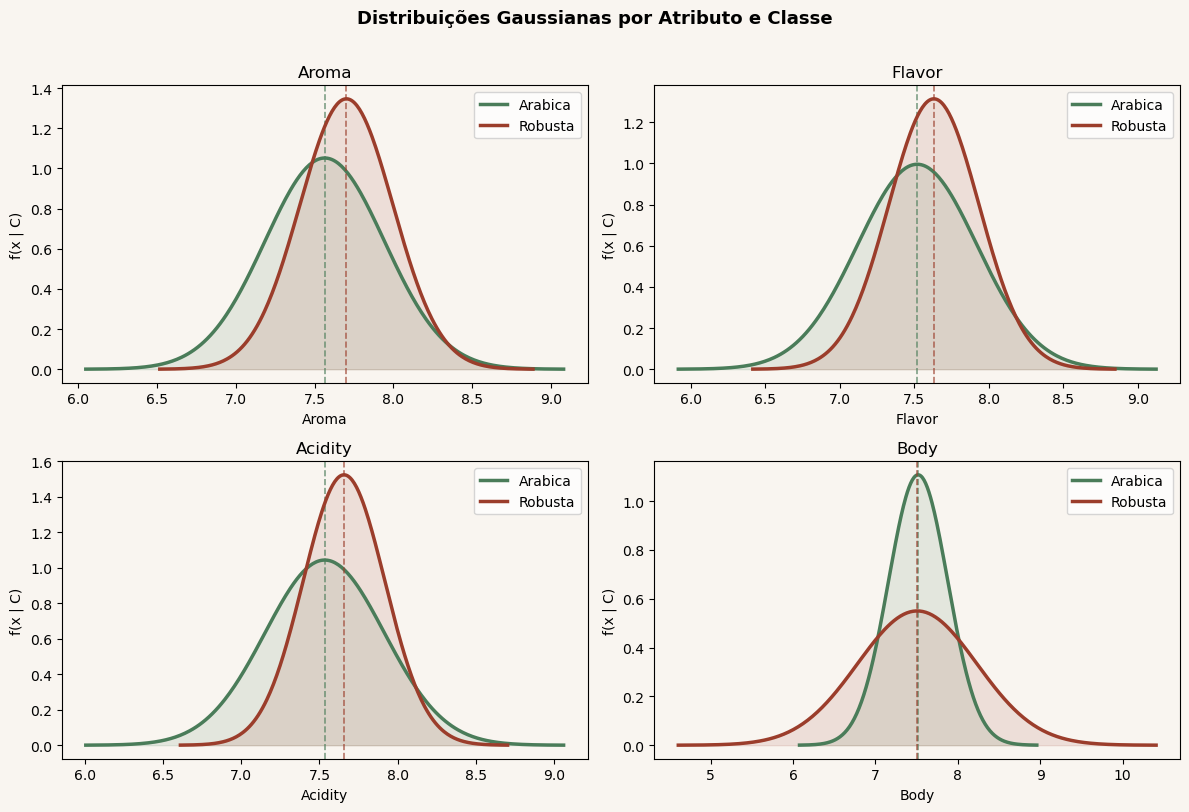

In [283]:
# Como as variáveis são contínuas, modelamos cada atributo como
# uma Normal dentro de cada classe: f(x | C) ~ N(μ, σ)
# Os parâmetros μ e σ são estimados diretamente dos dados de cada classe.

params = {}
for cls in CLASSES:
    subset = df[df[TARGET] == cls]
    params[cls] = {}
    for pred in PREDICTORS:
        params[cls][pred] = {
            'mean': subset[pred].mean(),
            'std' : subset[pred].std(ddof=1)
        }
 
print()
header = f"{'Variável':12s} | {'μ Arabica':>10} {'σ Arabica':>10} | {'μ Robusta':>10} {'σ Robusta':>10}"
print(header)
print("-" * len(header))
for pred in PREDICTORS:
    mA = params['Arabica'][pred]['mean']
    sA = params['Arabica'][pred]['std']
    mR = params['Robusta'][pred]['mean']
    sR = params['Robusta'][pred]['std']
    print(f"  {pred:10s} | {mA:>10.4f} {sA:>10.4f} | {mR:>10.4f} {sR:>10.4f}")
 
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for idx, pred in enumerate(PREDICTORS):
    ax = axes[idx]
    for cls, cor in cores.items():
        mu  = params[cls][pred]['mean']
        sig = params[cls][pred]['std']
        x_range = np.linspace(mu - 4*sig, mu + 4*sig, 300)
        ax.plot(x_range, norm.pdf(x_range, mu, sig), color=cor, linewidth=2.5, label=cls)
        ax.axvline(mu, color=cor, linestyle='--', linewidth=1.2, alpha=0.7)
        ax.fill_between(x_range, norm.pdf(x_range, mu, sig), alpha=0.12, color=cor)
    ax.set_title(f'{pred}')
    ax.set_xlabel(pred)
    ax.set_ylabel('f(x | C)')
    ax.legend()
    ax.set_facecolor('#f9f5f0')
fig.patch.set_facecolor('#f9f5f0')
plt.suptitle('Distribuições Gaussianas por Atributo e Classe', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('grafico_verossimilhancas.png', dpi=150, bbox_inches='tight')
plt.show()
 

#### Função de densidade Gaussiana implementada do zero

##### f(x | μ, σ) = 1/(σ√(2π)) × exp(−(x−μ)² / (2σ²))

In [284]:
def gaussian_pdf(x, mean, std):
    coeff    = 1.0 / (std * np.sqrt(2 * np.pi))
    exponent = -0.5 * ((x - mean) / std) ** 2
    return coeff * np.exp(exponent)

### 2.4.5 Teorema de Bayes - Classificação de Novo dado

In [285]:

def naive_bayes_predict(observacao, verbose=True):
    if verbose:
        print()
        print(f"Observação: {observacao}")
 
    # passo 1: inicializa com o log da priori
    log_scores = {cls: np.log(priors[cls]) for cls in CLASSES}
 
    if verbose:
        print()
        print("Passo 1 — log P(C):")
        for cls in CLASSES:
            print(f"  log P({cls}) = {log_scores[cls]:.6f}")
 
    # passo 2: acumula o log de cada verossimilhança
    likelihoods = {cls: {} for cls in CLASSES}
 
    if verbose:
        print()
        print("Passo 2 — verossimilhanças f(x | C):")
 
    for pred in PREDICTORS:
        x = observacao[pred]
        if verbose:
            print(f"\n  {pred} = {x}")
        for cls in CLASSES:
            mu  = params[cls][pred]['mean']
            sig = params[cls][pred]['std']
            lik = gaussian_pdf(x, mu, sig)
            likelihoods[cls][pred] = lik
            log_scores[cls] += np.log(lik)
            if verbose:
                print(f"    f({x} | {cls}): μ={mu:.4f}, σ={sig:.4f}  →  {lik:.6f}  (log={np.log(lik):.6f})")
 
    # passo 3: score total por classe
    if verbose:
        print()
        print("Passo 3 — log score acumulado:")
        for cls in CLASSES:
            print(f"  log score({cls}) = {log_scores[cls]:.6f}")
 
    # passo 4: normalização via log-sum-exp
    max_log    = max(log_scores.values())
    exp_scores = {cls: np.exp(log_scores[cls] - max_log) for cls in CLASSES}
    total_exp  = sum(exp_scores.values())
    posteriors = {cls: exp_scores[cls] / total_exp for cls in CLASSES}
 
    if verbose:
        print()
        print("Passo 4 — probabilidades posteriori:")
        for cls, p in posteriors.items():
            print(f"  P({cls} | dados) = {p:.6f}  ({p*100:.2f}%)")
        winner = max(posteriors, key=posteriors.get)
        print()
        print(f"Resultado: {winner}  ({posteriors[winner]*100:.2f}%)")
 
    return posteriors

#### exemplo pratico


Observação: {'Aroma': 7.8, 'Flavor': 7.6, 'Acidity': 7.5, 'Body': 7.7}

Passo 1 — log P(C):
  log P(Arabica) = -0.021277
  log P(Robusta) = -3.860730

Passo 2 — verossimilhanças f(x | C):

  Aroma = 7.8
    f(7.8 | Arabica): μ=7.5648, σ=0.3791  →  0.867976  (log=-0.141591)
    f(7.8 | Robusta): μ=7.7025, σ=0.2962  →  1.276010  (log=0.243738)

  Flavor = 7.6
    f(7.6 | Arabica): μ=7.5188, σ=0.4006  →  0.975530  (log=-0.024774)
    f(7.6 | Robusta): μ=7.6307, σ=0.3037  →  1.307094  (log=0.267806)

  Acidity = 7.5
    f(7.5 | Arabica): μ=7.5336, σ=0.3823  →  1.039573  (log=0.038810)
    f(7.5 | Robusta): μ=7.6571, σ=0.2618  →  1.272723  (log=0.241159)

  Body = 7.7
    f(7.7 | Arabica): μ=7.5183, σ=0.3601  →  0.975366  (log=-0.024943)
    f(7.7 | Robusta): μ=7.5068, σ=0.7252  →  0.530964  (log=-0.633061)

Passo 3 — log score acumulado:
  log score(Arabica) = -0.173776
  log score(Robusta) = -3.741087

Passo 4 — probabilidades posteriori:
  P(Arabica | dados) = 0.972543  (97.25%)
  P(Rob

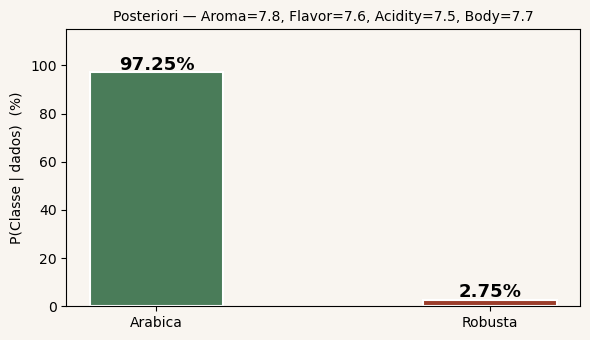

In [286]:
novo_cafe = {
    'Aroma'  : 7.80,
    'Flavor' : 7.60,
    'Acidity': 7.50,
    'Body'   : 7.70
}
 
resultado = naive_bayes_predict(novo_cafe, verbose=True)
 
fig, ax = plt.subplots(figsize=(6, 3.5))
classes_list = list(resultado.keys())
probs_list   = [resultado[c] * 100 for c in classes_list]
bars = ax.bar(classes_list, probs_list,
              color=[cores[c] for c in classes_list],
              width=0.4, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, probs_list):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.2f}%', ha='center', fontsize=13, fontweight='bold')
ax.set_ylim(0, 115)
ax.set_ylabel('P(Classe | dados)  (%)')
ax.set_title(f'Posteriori — Aroma={novo_cafe["Aroma"]}, Flavor={novo_cafe["Flavor"]}, '
             f'Acidity={novo_cafe["Acidity"]}, Body={novo_cafe["Body"]}', fontsize=10)
ax.set_facecolor('#f9f5f0')
fig.patch.set_facecolor('#f9f5f0')
plt.tight_layout()
plt.savefig('grafico_posteriori.png', dpi=150, bbox_inches='tight')
plt.show()

#### teste de multiplos cenarios

In [287]:
cenarios = [
    {'nome': 'Café leve (acidez alta)',   'obs': {'Aroma': 7.4, 'Flavor': 7.3, 'Acidity': 7.9, 'Body': 7.2}},
    {'nome': 'Café encorpado',            'obs': {'Aroma': 7.9, 'Flavor': 7.8, 'Acidity': 7.7, 'Body': 7.6}},
    {'nome': 'Café equilibrado',          'obs': {'Aroma': 7.6, 'Flavor': 7.5, 'Acidity': 7.5, 'Body': 7.5}},
    {'nome': 'Notas altas em tudo',       'obs': {'Aroma': 8.5, 'Flavor': 8.4, 'Acidity': 8.2, 'Body': 8.3}},
]
 
print()
print(f"{'Cenário':30s} | {'P(Arabica)':>12} | {'P(Robusta)':>12} | {'Resultado':>10}")
print("-" * 73)
for c in cenarios:
    res    = naive_bayes_predict(c['obs'], verbose=False)
    winner = max(res, key=res.get)
    print(f"  {c['nome']:28s} | {res['Arabica']*100:>10.2f}% | {res['Robusta']*100:>10.2f}% | {winner:>10}")
 
 


Cenário                        |   P(Arabica) |   P(Robusta) |  Resultado
-------------------------------------------------------------------------
  Café leve (acidez alta)      |      98.49% |       1.51% |    Arabica
  Café encorpado               |      96.37% |       3.63% |    Arabica
  Café equilibrado             |      98.13% |       1.87% |    Arabica
  Notas altas em tudo          |      97.98% |       2.02% |    Arabica


### 2.4.6 Resumo e resultados

In [288]:
print()
print("8. RESUMO CONCEITUAL")
print("""
  A ideia central do Teorema de Bayes é simples: a probabilidade
  de uma hipótese muda quando a gente observa evidências novas.
 
  No nosso caso, a "hipótese" é a espécie do café, e as
  "evidências" são as notas sensoriais de Aroma, Flavor,
  Acidity e Body.
 
  ┌─────────────────────────────────────────────────────────┐
  │  P(Classe | dados) ∝ P(Classe) × P(dados | Classe)      │
  └─────────────────────────────────────────────────────────┘
 
  P(Classe) é a a priori — a frequência de cada espécie no
  dataset. Neste caso, 98% dos registros são Arabica, então o
  modelo já parte com uma forte inclinação para essa classe.
 
  P(dados | Classe) é a verossimilhança — mede o quanto as
  notas observadas são compatíveis com cada espécie. Usamos
  uma distribuição Normal porque as variáveis são contínuas:
  calculamos a média e o desvio padrão de cada atributo dentro
  de cada classe e avaliamos a densidade naquele ponto.
 
  O produto dos dois dá o score de cada classe. Normalizar
  esses scores (dividir pelo total) transforma tudo em
  probabilidade — é aí que o denominador do teorema entra,
  garantindo que a soma das classes seja igual a 1.
 
  O "Naive" do Naive Bayes vem da suposição de que os
  atributos são independentes entre si dentro de cada classe,
  o que permite multiplicar as densidades individualmente.
  É uma simplificação, mas que funciona bem na prática.
 
  Uma observação importante sobre este dataset: o desbalanceio
  entre classes (98% Arabica) faz com que a a priori pese
  muito no resultado final. Para mitigar isso em projetos
  reais, costuma-se usar técnicas de balanceamento ou ajustar
  o limiar de decisão manualmente.
""")


8. RESUMO CONCEITUAL

  A ideia central do Teorema de Bayes é simples: a probabilidade
  de uma hipótese muda quando a gente observa evidências novas.

  No nosso caso, a "hipótese" é a espécie do café, e as
  "evidências" são as notas sensoriais de Aroma, Flavor,
  Acidity e Body.

  ┌─────────────────────────────────────────────────────────┐
  │  P(Classe | dados) ∝ P(Classe) × P(dados | Classe)      │
  └─────────────────────────────────────────────────────────┘

  P(Classe) é a a priori — a frequência de cada espécie no
  dataset. Neste caso, 98% dos registros são Arabica, então o
  modelo já parte com uma forte inclinação para essa classe.

  P(dados | Classe) é a verossimilhança — mede o quanto as
  notas observadas são compatíveis com cada espécie. Usamos
  uma distribuição Normal porque as variáveis são contínuas:
  calculamos a média e o desvio padrão de cada atributo dentro
  de cada classe e avaliamos a densidade naquele ponto.

  O produto dos dois dá o score de cada class

## 2.5 Algoritmos de Classificação

### verificar distribuição das classes

In [289]:
print(df["Species"].value_counts())

print("\nPercentual:")
print(df["Species"].value_counts(normalize=True) * 100)

Species
Arabica    1302
Robusta      28
Name: count, dtype: int64

Percentual:
Species
Arabica    97.894737
Robusta     2.105263
Name: proportion, dtype: float64


### separar atributos e classes

In [290]:
X = df.drop("Species", axis=1)

X = X.select_dtypes(include=np.number)

y = df["Species"]

print(X.shape)

(1330, 20)


In [291]:
from sklearn.utils import shuffle

y_random = shuffle(y, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_random,
    test_size=0.3,
    random_state=42,
    stratify=y_random
)

nb = GaussianNB()
nb.fit(X_train, y_train)

print(nb.score(X_test, y_test))

0.2506265664160401


### divisão treino e teste

In [292]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (931, 20)
Teste: (399, 20)


In [293]:
nb = GaussianNB()

nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)



                     NAIVE BAYES

              precision    recall  f1-score   support

     Arabica       1.00      1.00      1.00       391
     Robusta       1.00      1.00      1.00         8

    accuracy                           1.00       399
   macro avg       1.00      1.00      1.00       399
weighted avg       1.00      1.00      1.00       399



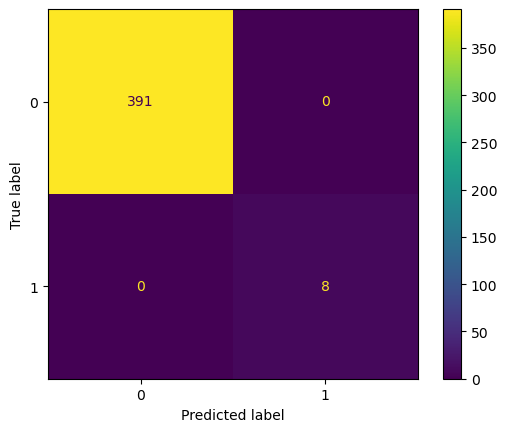

In [294]:
print("\n")
print("                     NAIVE BAYES\n")

print(classification_report(y_test, y_pred_nb))

cm = confusion_matrix(y_test, y_pred_nb)

disp = ConfusionMatrixDisplay(cm)

disp.plot()


plt.show()

In [295]:
tree = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42,
    max_depth=5
)

tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

=== ÁRVORE DE DECISÃO ===

              precision    recall  f1-score   support

     Arabica       1.00      1.00      1.00       391
     Robusta       1.00      0.88      0.93         8

    accuracy                           1.00       399
   macro avg       1.00      0.94      0.97       399
weighted avg       1.00      1.00      1.00       399



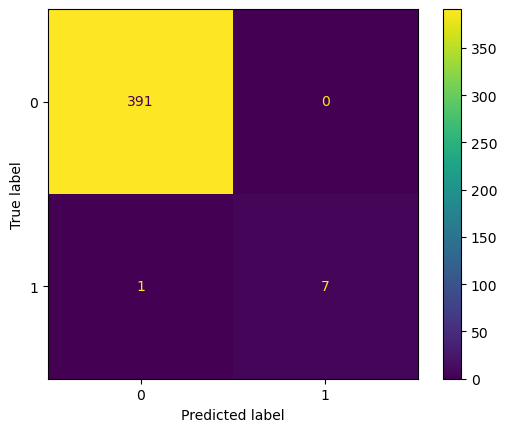

In [296]:
print("=== ÁRVORE DE DECISÃO ===\n")

print(classification_report(y_test, y_pred_tree))

cm = confusion_matrix(y_test, y_pred_tree)

disp = ConfusionMatrixDisplay(cm)

disp.plot()

plt.show()

In [297]:
knn = KNeighborsClassifier(
    n_neighbors=5,
    weights="distance"
)

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

=== KNN ===

              precision    recall  f1-score   support

     Arabica       0.99      0.99      0.99       391
     Robusta       0.67      0.50      0.57         8

    accuracy                           0.98       399
   macro avg       0.83      0.75      0.78       399
weighted avg       0.98      0.98      0.98       399



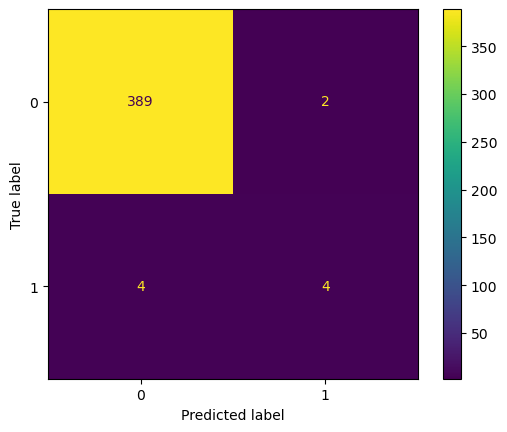

In [298]:
print("=== KNN ===\n")

print(classification_report(y_test, y_pred_knn))

cm = confusion_matrix(y_test, y_pred_knn)

disp = ConfusionMatrixDisplay(cm)

disp.plot()

plt.show()

In [299]:
resultados = pd.DataFrame({
    "Modelo": [
        "Naive Bayes",
        "Árvore de Decisão",
        "KNN"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_knn)
    ],

    "Precision": [
        precision_score(y_test, y_pred_nb, pos_label="Robusta", zero_division=0),
        precision_score(y_test, y_pred_tree, pos_label="Robusta", zero_division=0),
        precision_score(y_test, y_pred_knn, pos_label="Robusta", zero_division=0)
    ],

    "Recall": [
        recall_score(y_test, y_pred_nb, pos_label="Robusta", zero_division=0),
        recall_score(y_test, y_pred_tree, pos_label="Robusta", zero_division=0),
        recall_score(y_test, y_pred_knn, pos_label="Robusta", zero_division=0)
    ],

    "F1-Score": [
        f1_score(y_test, y_pred_nb, pos_label="Robusta", zero_division=0),
        f1_score(y_test, y_pred_tree, pos_label="Robusta", zero_division=0),
        f1_score(y_test, y_pred_knn, pos_label="Robusta", zero_division=0)
    ]
})

resultados.sort_values("F1-Score", ascending=False)

,Modelo,Accuracy,Precision,Recall,F1-Score
0,Naive Bayes,1.000000,1.000000,1.000,1.000000
1,Árvore de Decisão,0.997494,1.000000,0.875,0.933333
2,KNN,0.984962,0.666667,0.500,0.571429


In [300]:
melhor = resultados.loc[resultados["F1-Score"].idxmax()]

print(
    f"O modelo com melhor desempenho para identificar cafés Robusta "
    f"foi {melhor['Modelo']}, obtendo F1-Score de "
    f"{melhor['F1-Score']:.4f}."
)

O modelo com melhor desempenho para identificar cafés Robusta foi Naive Bayes, obtendo F1-Score de 1.0000.
